In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import seaborn as sns

from glob import glob

In [2]:
# Extract path
female_path = glob('../cropped_faces/females/*.jpg')
male_path = glob('../cropped_faces/males/*.jpg')

In [3]:
# Create one data frame
df_female = pd.DataFrame(female_path, columns = ['filepath'])
df_female['gender'] = 'female'
df_male = pd.DataFrame(male_path, columns = ['filepath'])
df_male['gender'] = 'male'

faces_dataframe = pd.concat((df_female, df_male), axis=0)

In [4]:
faces_dataframe.head()

,filepath,gender
0,../cropped_faces/females\females_0_0.jpg,female
1,../cropped_faces/females\females_0_1.jpg,female
2,../cropped_faces/females\females_1000_0.jpg,female
3,../cropped_faces/females\females_1001_0.jpg,female
4,../cropped_faces/females\females_1002_0.jpg,female


In [5]:
faces_dataframe.tail()

,filepath,gender
3715,../cropped_faces/males\males_994_0.jpg,male
3716,../cropped_faces/males\males_995_0.jpg,male
3717,../cropped_faces/males\males_996_0.jpg,male
3718,../cropped_faces/males\males_998_0.jpg,male
3719,../cropped_faces/males\males_9_0.jpg,male


In [6]:
faces_dataframe.shape

(7663, 2)

In [7]:
# Get the images width as size of the of the image
def get_size(img_path):
    img = cv2.imread(img_path)
    return img.shape[0]
    

In [8]:
# Store dimensions of image in columns 
faces_dataframe['dimension'] = faces_dataframe['filepath'].apply(get_size)

In [9]:
faces_dataframe.head()

,filepath,gender,dimension
0,../cropped_faces/females\females_0_0.jpg,female,273
1,../cropped_faces/females\females_0_1.jpg,female,116
2,../cropped_faces/females\females_1000_0.jpg,female,55
3,../cropped_faces/females\females_1001_0.jpg,female,60
4,../cropped_faces/females\females_1002_0.jpg,female,85


In [10]:
faces_dataframe['gender'].value_counts()

gender
female    3943
male      3720
Name: count, dtype: int64

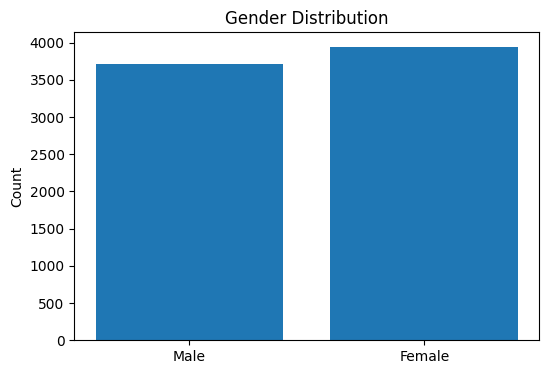

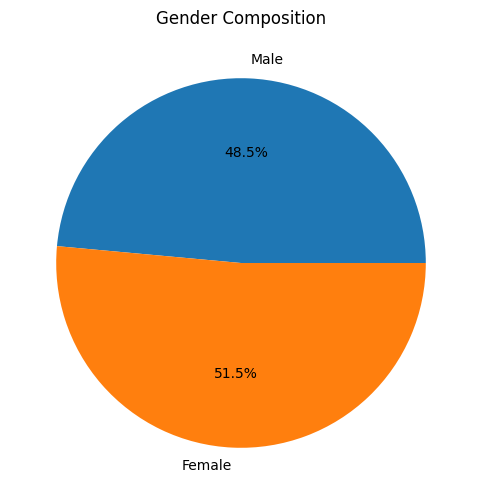

In [11]:
gender_counts = {
    'Male': 3720,
    'Female': 3943
}

# Bar Chart
plt.figure(figsize=(6,4))
plt.bar(gender_counts.keys(), gender_counts.values())
plt.title('Gender Distribution')
plt.ylabel('Count')
plt.show()

# Pie Chart
plt.figure(figsize=(6,6))
plt.pie(
    gender_counts.values(),
    labels=gender_counts.keys(),
    autopct='%1.1f%%'
)
plt.title('Gender Composition')
plt.show()

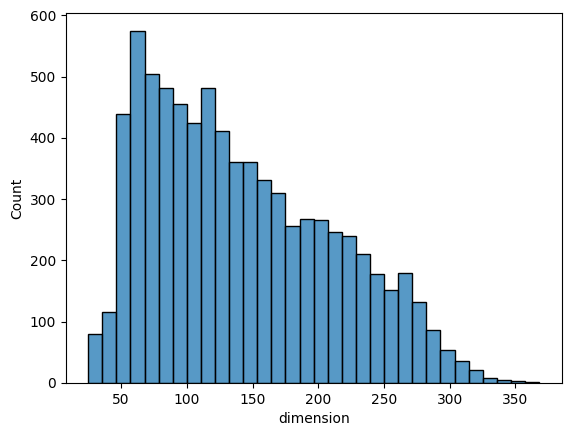

In [12]:
sns.histplot(faces_dataframe['dimension']);

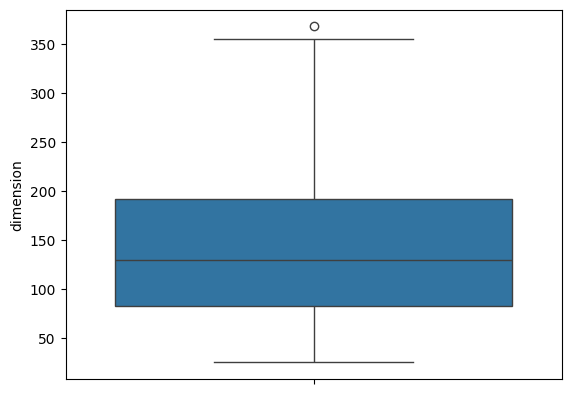

In [13]:
sns.boxplot(faces_dataframe['dimension']);

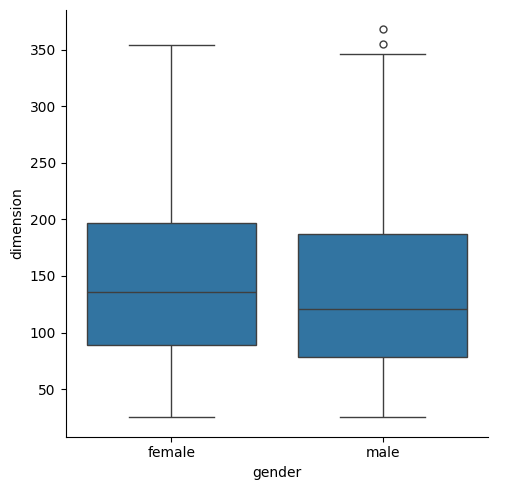

In [14]:
sns.catplot(data=faces_dataframe, x='gender', y='dimension', kind='box');

In [15]:
faces_dataframe_filter = faces_dataframe.query('dimension > 60')

In [16]:
faces_dataframe_filter.shape

(6840, 3)

In [17]:
faces_dataframe_filter['gender'].value_counts(normalize=True)

gender
female    0.523246
male      0.476754
Name: proportion, dtype: float64

In [21]:
def structuring_image(image_path):
    try:
        # Read Image
        img = cv2.imread(image_path)
    
        ## Covert image into grayscale
        gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        ### Resize into 100 x 100
        h, w = gray_image.shape
        if h >= 100 or w >= 100:
            gray_image_resize = cv2.resize(gray_image, (100, 100), cv2.INTER_AREA)
        else:
            gray_image_resize = cv2.resize(gray, (100, 100), cv2.INTER_CUBIC)
    
        #### Flatten Image (1x10000)
        return gray_image_resize.flatten()
    except:
        return None
    

In [22]:
faces_dataframe_filter['data'] = faces_dataframe_filter['filepath'].apply(structuring_image)

In [23]:
faces_dataframe_filter.head()

,filepath,gender,dimension,data
0,../cropped_faces/females\females_0_0.jpg,female,273,"[201, 200, 201, 195, 194, 180, 194, 190, 201, ..."
1,../cropped_faces/females\females_0_1.jpg,female,116,"[112, 115, 128, 145, 131, 109, 107, 117, 106, ..."
4,../cropped_faces/females\females_1002_0.jpg,female,85,None
6,../cropped_faces/females\females_1004_0.jpg,female,182,"[133, 134, 127, 119, 127, 132, 149, 147, 138, ..."
7,../cropped_faces/females\females_1005_0.jpg,female,146,"[80, 72, 67, 63, 57, 56, 56, 67, 74, 60, 66, 7..."
